# Gundam character war-death prediction with Random Forest

This notebook trains a Random Forest baseline for predicting `death_in_war_target`.

## Important

The current dataset contains confirmed positive labels (`1`) and `Unknown` rows.  
There is no fully verified negative class yet.  
This notebook therefore uses a weak baseline:

`Unknown -> 0`

This is useful for checking pipeline behavior and feature importance, but it is not a final factual survival/death model.


In [1]:
from pathlib import Path
import os

if Path.cwd().name == "notebooks":
    os.chdir("..")

Path.cwd()

PosixPath('/workspace')

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

from gundam_rf.data import load_dataset, make_weak_binary_target, summarize_labels
from gundam_rf.features import build_feature_frame
from gundam_rf.train import make_pipeline, evaluate_model, get_feature_importance
from sklearn.model_selection import train_test_split

DATA_PATH = Path("data/raw/gundam_character_death_dataset_first_pass.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Load dataset

In [3]:
df = load_dataset(DATA_PATH)
print(df.shape)
df.head()


(2905, 29)


,character_id,source_line,character_name_jp,raw_name_jp,aliases_or_alt_names_jp,appearance_note_jp,character_name_en,universe_jp,universe_code,work_title_jp,...,row_order_in_source,death_in_war_target,death_status_label,death_label_confidence,death_label_note,death_label_source_url,voice_actor_jp,voice_actor_source_url,row_research_status,needs_manual_review
0,gundam_char_0001,9,アントニオ・カラス,アントニオ・カラス,Unknown,Unknown,Unknown,『機動戦士ガンダム』（宇宙世紀）シリーズ,UC / alternate UC,機動戦士ガンダム,...,1,Unknown,Unknown,Unknown,Unknown / not verified in this pass,Unknown,Unknown,Unknown,Not row-level verified,True
1,gundam_char_0002,10,ウッディ・マルデン,ウッディ・マルデン,Unknown,Unknown,Unknown,『機動戦士ガンダム』（宇宙世紀）シリーズ,UC / alternate UC,機動戦士ガンダム,...,2,1,Killed in action / death during armed conflict,Medium,Matched to manual researched death seed list; ...,https://gundam.fandom.com/wiki/Category:Deceased,Unknown,Unknown,Seed death label matched,False
2,gundam_char_0003,11,エルラン,エルラン,Unknown,Unknown,Unknown,『機動戦士ガンダム』（宇宙世紀）シリーズ,UC / alternate UC,機動戦士ガンダム,...,3,Unknown,Unknown,Unknown,Unknown / not verified in this pass,Unknown,Unknown,Unknown,Not row-level verified,True
3,gundam_char_0004,12,カミラ,カミラ,Unknown,Unknown,Unknown,『機動戦士ガンダム』（宇宙世紀）シリーズ,UC / alternate UC,機動戦士ガンダム,...,4,Unknown,Unknown,Unknown,Unknown / not verified in this pass,Unknown,Unknown,Unknown,Not row-level verified,True
4,gundam_char_0005,13,コーリン,コーリン,Unknown,Unknown,Unknown,『機動戦士ガンダム』（宇宙世紀）シリーズ,UC / alternate UC,機動戦士ガンダム,...,5,Unknown,Unknown,Unknown,Unknown / not verified in this pass,Unknown,Unknown,Unknown,Not row-level verified,True


## 2. Check original label distribution

In [4]:
label_summary = summarize_labels(df)
label_summary


,death_in_war_target,count
0,Unknown,2693
1,1,212


## 3. Create weak binary target

`Unknown` is converted to `0` for this baseline only.


In [5]:
y = make_weak_binary_target(df, unknown_as_negative=True)
y.value_counts().sort_index().rename_axis("weak_label").reset_index(name="count")


,weak_label,count
0,0,2693
1,1,212


## 4. Build leakage-safe feature frame

In [6]:
X = build_feature_frame(df)
print(X.shape)
X.head()


(2905, 25)


,universe_code,work_title_jp,medium_hint,canon_tier_hint,faction_family,affiliation_context_jp,is_military_or_combat_faction_proxy,is_zeon_related_proxy,is_federation_related_proxy,is_named_pilot_or_fighter_proxy,...,raw_name_jp_is_known,aliases_or_alt_names_jp_char_len,aliases_or_alt_names_jp_is_known,appearance_note_jp_char_len,appearance_note_jp_is_known,character_name_en_char_len,character_name_en_is_known,affiliation_context_jp_char_len,affiliation_context_jp_is_known,has_voice_actor_jp
0,UC / alternate UC,機動戦士ガンダム,TV anime + Movie + Novel,Primary animation / screen work,Earth Federation / Londo Bell / Titans,地球連邦軍,1,0,1,0,...,1,7,0,7,0,7,0,5,1,0
1,UC / alternate UC,機動戦士ガンダム,TV anime + Movie + Novel,Primary animation / screen work,Earth Federation / Londo Bell / Titans,地球連邦軍,1,0,1,0,...,1,7,0,7,0,7,0,5,1,0
2,UC / alternate UC,機動戦士ガンダム,TV anime + Movie + Novel,Primary animation / screen work,Earth Federation / Londo Bell / Titans,地球連邦軍,1,0,1,0,...,1,7,0,7,0,7,0,5,1,0
3,UC / alternate UC,機動戦士ガンダム,TV anime + Movie + Novel,Primary animation / screen work,Earth Federation / Londo Bell / Titans,地球連邦軍,1,0,1,0,...,1,7,0,7,0,7,0,5,1,0
4,UC / alternate UC,機動戦士ガンダム,TV anime + Movie + Novel,Primary animation / screen work,Earth Federation / Londo Bell / Titans,地球連邦軍,1,0,1,0,...,1,7,0,7,0,7,0,5,1,0


## 5. Train/test split

In [7]:
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X,
    y,
    df,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("train:", X_train.shape, y_train.value_counts().sort_index().to_dict())
print("test :", X_test.shape, y_test.value_counts().sort_index().to_dict())


train: (2178, 25) {0: 2019, 1: 159}
test : (727, 25) {0: 674, 1: 53}


## 6. Train Random Forest

In [8]:
model = make_pipeline(X_train, random_state=42)
model.fit(X_train, y_train)
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## 7. Evaluate holdout performance

In [9]:
metrics = evaluate_model(model, X_test, y_test)
print(json.dumps({
    "balanced_accuracy": metrics["balanced_accuracy"],
    "roc_auc": metrics["roc_auc"],
    "average_precision": metrics["average_precision"],
    "confusion_matrix": metrics["confusion_matrix"],
    "per_class": metrics["per_class"],
}, ensure_ascii=False, indent=2))


{
  "balanced_accuracy": 0.7238816415654219,
  "roc_auc": 0.8589384692906332,
  "average_precision": 0.3471801280596697,
  "confusion_matrix": [
    [
      607,
      67
    ],
    [
      24,
      29
    ]
  ],
  "per_class": {
    "0": {
      "precision": 0.9619651347068146,
      "recall": 0.900593471810089,
      "f1": 0.9302681992337165,
      "support": 674
    },
    "1": {
      "precision": 0.3020833333333333,
      "recall": 0.5471698113207547,
      "f1": 0.38926174496644295,
      "support": 53
    }
  }
}


## 8. Feature importance

In [10]:
feature_importance = get_feature_importance(model)
feature_importance.head(30)


,feature,importance
0,numeric__raw_name_jp_char_len,0.112984
1,numeric__character_name_jp_char_len,0.103386
2,numeric__affiliation_context_jp_char_len,0.057736
3,categorical__canon_tier_hint_Primary animation...,0.055407
4,numeric__is_military_or_combat_faction_proxy,0.047462
5,categorical__canon_tier_hint_Expanded universe...,0.041651
6,categorical__faction_family_Civilian / Other,0.029467
7,categorical__universe_code_UC / alternate UC,0.025451
8,categorical__work_title_jp_機動戦士ガンダム C.D.A. 若き彗...,0.016694
9,categorical__medium_hint_TV anime,0.015400


/tmp/ipykernel_94/64451282.py:8: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94/64451282.py:8: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94/64451282.py:8: UserWarning: Glyph 36899 (\N{CJK UNIFIED IDEOGRAPH-9023}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94/64451282.py:8: UserWarning: Glyph 37030 (\N{CJK UNIFIED IDEOGRAPH-90A6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94/64451282.py:8: UserWarning: Glyph 36557 (\N{CJK UNIFIED IDEOGRAPH-8ECD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94/64451282.py:8: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94/64451282.py:8: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.

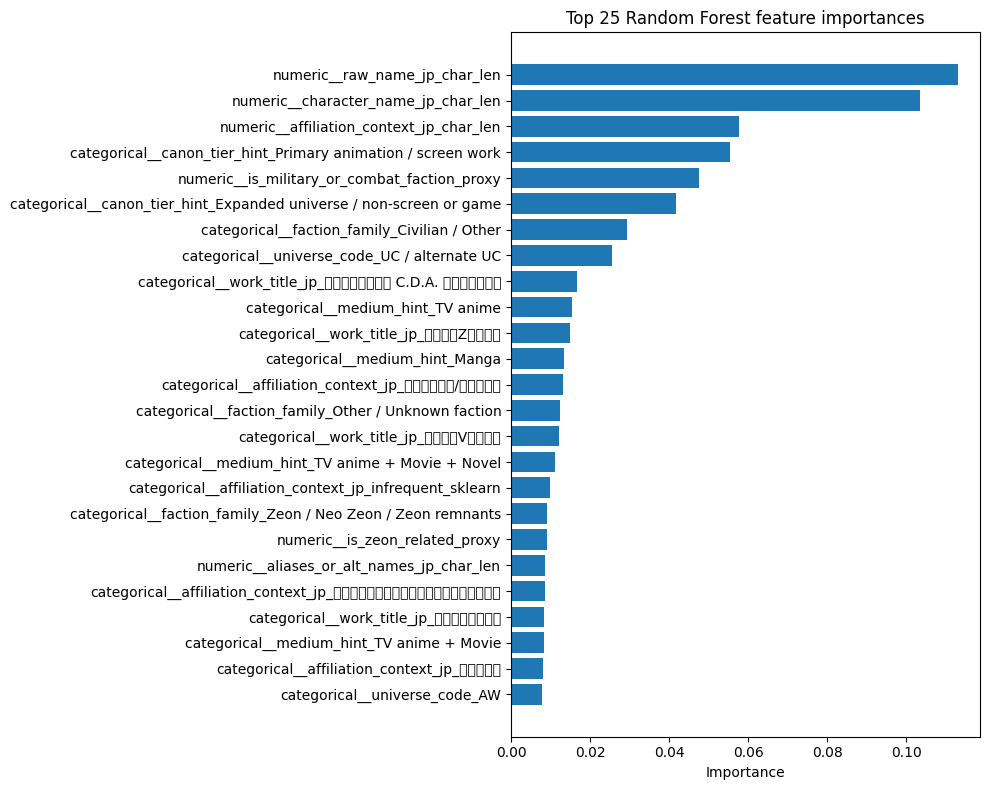

In [11]:
top_n = 25
plot_df = feature_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title(f"Top {top_n} Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 9. Inspect high-probability holdout predictions

In [12]:
predictions = df_test[
    [
        col for col in [
            "character_id",
            "character_name_jp",
            "character_name_en",
            "universe_code",
            "work_title_jp",
            "death_in_war_target",
            "death_status_label",
            "needs_manual_review",
        ]
        if col in df_test.columns
    ]
].copy()

predictions["y_true_weak"] = y_test.values
predictions["predicted_probability_death"] = model.predict_proba(X_test)[:, 1]
predictions["predicted_label_weak"] = model.predict(X_test)

predictions.sort_values("predicted_probability_death", ascending=False).head(30)


,character_id,character_name_jp,character_name_en,universe_code,work_title_jp,death_in_war_target,death_status_label,needs_manual_review,y_true_weak,predicted_probability_death,predicted_label_weak
622,gundam_char_0623,ジャミトフ・ハイマン,Unknown,UC / alternate UC,機動戦士Ζガンダム,1,Killed in action / death during armed conflict,False,1,0.974549,1
642,gundam_char_0643,レコア・ロンド,Unknown,UC / alternate UC,機動戦士Ζガンダム,1,Killed in action / death during armed conflict,False,1,0.921389,1
617,gundam_char_0618,ゲーツ・キャパ,Unknown,UC / alternate UC,機動戦士Ζガンダム,Unknown,Unknown,True,0,0.921389,1
744,gundam_char_0745,ヘンケン・ベッケナー,Unknown,UC / alternate UC,機動戦士ガンダム C.D.A. 若き彗星の肖像,1,Killed in action / death during armed conflict,False,1,0.890168,1
734,gundam_char_0735,グリーン・ワイワット,Unknown,UC / alternate UC,機動戦士ガンダム C.D.A. 若き彗星の肖像,Unknown,Unknown,True,0,0.890168,1
621,gundam_char_0622,ジャマイカン・ダニンガン,Unknown,UC / alternate UC,機動戦士Ζガンダム,1,Killed in action / death during armed conflict,False,1,0.879757,1
60,gundam_char_0061,ジンバ・ラル,Unknown,UC / alternate UC,機動戦士ガンダム,Unknown,Unknown,True,0,0.872336,1
117,gundam_char_0118,コズン・グラハム,Unknown,UC / alternate UC,機動戦士ガンダム,1,Killed in action / death during armed conflict,False,1,0.867407,1
1329,gundam_char_1330,ヘレン・ジャクソン,Unknown,UC / alternate UC,機動戦士Vガンダム,1,Killed in action / death during armed conflict,False,1,0.860904,1
448,gundam_char_0449,アンディ・ストロース,Unknown,UC / alternate UC,機動戦士ガンダム0080 ポケットの中の戦争,1,Killed in action / death during armed conflict,False,1,0.833711,1


## 10. Save outputs

In [13]:
feature_importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
predictions.sort_values("predicted_probability_death", ascending=False).to_csv(
    OUTPUT_DIR / "predictions_holdout.csv",
    index=False,
)

with (OUTPUT_DIR / "metrics.json").open("w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Saved:")
print(OUTPUT_DIR / "feature_importance.csv")
print(OUTPUT_DIR / "predictions_holdout.csv")
print(OUTPUT_DIR / "metrics.json")


Saved:
outputs/feature_importance.csv
outputs/predictions_holdout.csv
outputs/metrics.json


## 11. Interpretation checklist

Use this checklist before trusting the model:

- Are confirmed non-death rows available?
- Are `Unknown` rows separated from true negatives?
- Are label-source URLs filled?
- Are proxy features causing unintended leakage?
- Are high-probability predictions manually plausible?
